# 14. Uncertainties — Dummy Experiments

**Goal:** explore how to quantify the uncertainty of the optimized parameters (μ, γ) recovered by the 12c pipeline.

**Experiment 1 — Bootstrap:** take the target data, make bootstrap copies (resample with replacement), re-run the full 12c optimization on each copy, and look at the distribution of the resulting optimal values. The spread of that distribution is the uncertainty of the point estimate.

**Why bootstrap first:** simplest method, zero new machinery — it wraps the existing optimizer as-is.

**Honest caveats:**
- The cloud mixes *data noise* (bootstrap resampling) with *optimizer noise* (stochastic REINFORCE + implicit-diff gradients) — this is the total variability of the whole procedure.
- Bootstrap measures variance of the estimator, not bias. On synthetic data we know the truth, so we can check bias and coverage for free.
- The optimizer is expensive (~4–7 min per run) → K replicas are parallelized across cores.


In [1]:
import math, time, json, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

# make sure the repo root (with src/) is importable regardless of cwd
for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p)
        REPO_ROOT = _p
        break

os.chdir(REPO_ROOT)   # anchor all relative paths at the repo root
torch.set_default_dtype(torch.float32)

from src.fitting import (
    _raw_from_width as _rw,
    log_pdf, nll, fwhm_from_theta, fit_profile
)
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


## Constants (identical to 12c)

Same hyperparameters as `12c-joint-opt-with-sigma-mean-fwhm.ipynb` — nothing changed.


In [2]:
# --- constants (identical to 12c) ---
GAMMA_TRUE = 20.0
NBAR_TRUE = 50.0
LAMBDA_ = 2.0
N_TARGET = 200
N_RUNS = 200
N_ITER = 80
SIGMA_PROP = 6.0
LR_MU = 15.0
LR_GAMMA = 0.5
BASELINE_ALPHA = 0.05
CLIP = 10.0
LAMBDA_SIGMA = 0.3
LAMBDA_GAMMA_SIGMA = 0.3
LAMBDA_MEAN = 0.3
MU_INIT = 8.0
GAMMA_INIT = 5.0
SEED = 42

# --- experiment settings ---
K_BOOTSTRAP = 30        # number of bootstrap replicas
N_WORKERS = 4           # parallel workers (one per core)

print('Parameters set')

Parameters set


## Refactored 12c optimization loop

The 12c loop, wrapped into `run_optimization(target_fwhms, target_sigmas, seed, ...)`.
Same math, same order, same hyperparameters — only the prints are silenced and the
result is returned as `(mu_final, gamma_final, history)`.


In [3]:
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)

def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')

def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)


def run_optimization(target_fwhms, target_sigmas, seed=SEED,
                     n_iter=N_ITER, n_runs=N_RUNS, quiet=True):
    """12c joint optimization loop, refactored into a function.

    Returns (mu_final, gamma_final, history).
    """
    target_t = torch.tensor(target_fwhms, dtype=torch.float32)
    target_s_t = torch.tensor(target_sigmas, dtype=torch.float32)
    st, _ = torch.sort(target_t)
    st_sig, _ = torch.sort(target_s_t)

    mu_val = float(MU_INIT)
    gamma_val = float(GAMMA_INIT)
    bl = 0.0
    history = []
    t0 = time.time()

    for step in range(n_iter):
        rng2 = np.random.default_rng(seed + step)
        fwhms, sigmas, dfs, ns = [], [], [], []

        for _ in range(n_runs):
            u, b, n = draw_fixed_noise(mu_val, SIGMA_PROP, LAMBDA_, rng2)
            ns.append(n)
            fw, sig, dg = compute_fwhm_and_dgamma(
                gamma_val, u.numpy(), b.numpy(),
                _fit_fn, _fwhm_fn, _nll_fn, n_params=2
            )
            fwhms.append(fw)
            sigmas.append(sig)
            dfs.append(dg)

        ft = torch.tensor(fwhms, dtype=torch.float32)
        si_t = torch.tensor(sigmas, dtype=torch.float32)
        nt = torch.tensor(ns, dtype=torch.float32)
        dg_t = torch.tensor(dfs, dtype=torch.float32)

        sf, sidx = torch.sort(ft)
        pl = torch.abs(sf - st[:n_runs])
        nss = nt[sidx]
        dgs = dg_t[sidx]
        ss = si_t[sidx]

        pl_sig = torch.abs(ss - st_sig[:n_runs])
        mean_fwhm_loss = torch.abs(ft.mean() - target_t.mean())
        cl = pl + LAMBDA_SIGMA * pl_sig + LAMBDA_MEAN * mean_fwhm_loss

        loss_fwhm = pl.mean()
        loss_sigma = pl_sig.mean()
        mean_loss = (loss_fwhm + LAMBDA_SIGMA * loss_sigma + LAMBDA_MEAN * mean_fwhm_loss).item()
        loss_fwhm_val = loss_fwhm.item()
        loss_sigma_val = loss_sigma.item()
        mean_fwhm_val = mean_fwhm_loss.item()

        if step == 0:
            bl = mean_loss
        else:
            bl = (1 - BASELINE_ALPHA) * bl + BASELINE_ALPHA * mean_loss

        lr_mu_decay = LR_MU * max(0.3, 1.0 - step / n_iter)
        adv = (cl.detach() - bl).numpy()
        scores = (nss.numpy() - mu_val) / SIGMA_PROP**2
        raw_grad_mu = float(np.mean(adv * scores))
        grad_mu = max(min(raw_grad_mu, CLIP), -CLIP)
        mu_val += lr_mu_decay * (-grad_mu)
        mu_val = max(1.0, min(200.0, mu_val))

        dsigs = torch.tensor([min(2.0 / math.sqrt(max(int(n), 1)), 2.0) for n in ns], dtype=torch.float32)
        ds_s = dsigs[sidx]
        signs_fw = torch.sign(sf - st[:n_runs])
        signs_sg = torch.sign(ss - st_sig[:n_runs])
        raw_grad_fwhm = float((signs_fw * dgs).mean().item())
        raw_grad_sigma = float((signs_sg * ds_s).mean().item())
        raw_grad_gamma = raw_grad_fwhm + LAMBDA_GAMMA_SIGMA * raw_grad_sigma
        grad_gamma = max(min(raw_grad_gamma, CLIP), -CLIP)
        gamma_val += LR_GAMMA * (-grad_gamma)
        gamma_val = max(0.1, min(100.0, gamma_val))

        rho = float(np.corrcoef(nss.numpy(), pl.numpy())[0, 1]) if pl.std() > 0.01 and nss.std() > 0.01 else 0.0

        history.append({
            'step': step, 'mu': mu_val, 'gamma': gamma_val,
            'loss': mean_loss, 'loss_fwhm': loss_fwhm_val, 'loss_sigma': loss_sigma_val,
            'mean_fwhm_diff': mean_fwhm_val, 'baseline': bl,
            'grad_mu': grad_mu, 'grad_gamma': grad_gamma,
            'rho': rho, 'mean_n': float(np.mean(ns)),
            'mean_fwhm': float(ft.mean().item()),
            'mean_sigma': float(ss.mean().item()),
        })
        if not quiet and (step % 5 == 0 or step == n_iter - 1):
            print(f"  S{step:2d}: mu={mu_val:6.2f} gamma={gamma_val:5.1f} | L={mean_loss:.2f} ({time.time()-t0:.0f}s)", flush=True)

    return mu_val, gamma_val, history


def bootstrap_replica(k, target_fwhms, target_sigmas):
    """One bootstrap replica: resample pairs, run optimizer, return results."""
    torch.set_num_threads(1)   # avoid OpenMP oversubscription across workers
    rng = np.random.default_rng(1000 + k)
    idx = rng.integers(0, len(target_fwhms), len(target_fwhms))
    tf = np.asarray(target_fwhms)[idx]
    ts = np.asarray(target_sigmas)[idx]
    t0 = time.time()
    mu, gam, hist = run_optimization(tf, ts, seed=2000 + k)
    return {
        'k': k,
        'mu': float(mu), 'gamma': float(gam),
        'loss': float(hist[-1]['loss']),
        'loss_fwhm': float(hist[-1]['loss_fwhm']),
        'time_s': time.time() - t0,
    }

## Generate base target (as in 12c)

200 runs at the true parameters (μ=50, γ=20). This is the "observed data" we will bootstrap.


In [4]:
print(f"Generating base target ({N_TARGET} runs at truth)...", flush=True)
rng = np.random.default_rng(SEED)
base_fwhms, base_sigmas = [], []
for ti in range(N_TARGET):
    u, b, n = draw_fixed_noise(NBAR_TRUE, 6, LAMBDA_, rng)
    fw, sig, _ = compute_fwhm_and_dgamma(
        GAMMA_TRUE, u.numpy(), b.numpy(),
        _fit_fn, _fwhm_fn, _nll_fn, n_params=2
    )
    base_fwhms.append(fw)
    base_sigmas.append(sig)
base_fwhms = np.array(base_fwhms)
base_sigmas = np.array(base_sigmas)
print(f"Base target: FWHM mean={base_fwhms.mean():.1f} ± {base_fwhms.std():.1f}, sigma mean={base_sigmas.mean():.2f}")

Generating base target (200 runs at truth)...


Base target: FWHM mean=42.3 ± 10.5, sigma mean=1.42


## Experiment 1: Bootstrap

For each replica k:
1. Resample the 200 **(FWHM, σ) pairs with replacement** → new target distribution
2. Run the full 12c optimization on that target (its own random seed)
3. Record the final (μ̂, γ̂)

Repeat K times, in parallel. The distribution of (μ̂, γ̂) is the uncertainty.

*Results are cached to `data/processed/bootstrap_results.json` — if the file exists with the same K, it is loaded instead of re-running.*


In [5]:
RESULTS_PATH = 'data/processed/bootstrap_results.json'

if os.path.exists(RESULTS_PATH):
    cached = json.load(open(RESULTS_PATH))
    if cached.get('K') == K_BOOTSTRAP:
        results = cached['results']
        print(f"Loaded cached results ({len(results)} replicas) from {RESULTS_PATH}")
    else:
        results = None
else:
    results = None

if results is None:
    import multiprocessing as mp
    mp.set_start_method("fork", force=True)   # py3.14 defaults to forkserver; notebook functions need fork
    from concurrent.futures import ProcessPoolExecutor
    print(f"Running {K_BOOTSTRAP} bootstrap replicas on {N_WORKERS} workers "
          f"(~4 min each, parallel)...", flush=True)
    t_start = time.time()
    with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = [pool.submit(bootstrap_replica, k, base_fwhms, base_sigmas)
                   for k in range(K_BOOTSTRAP)]
        results = []
        for i, f in enumerate(futures):
            res = f.result()
            results.append(res)
            # incremental save: never lose completed replicas on crash
            json.dump({'K': K_BOOTSTRAP, 'results': results},
                      open(RESULTS_PATH, 'w'), indent=1)
            done = i + 1
            print(f"  [{done}/{K_BOOTSTRAP}] replica {res['k']:2d}: "
                  f"mu={res['mu']:6.2f} gamma={res['gamma']:5.2f} "
                  f"({res['time_s']:.0f}s)", flush=True)
    results.sort(key=lambda r: r['k'])
    json.dump({'K': K_BOOTSTRAP, 'results': results},
              open(RESULTS_PATH, 'w'), indent=1)
    print(f"Saved to {RESULTS_PATH} — total {time.time()-t_start:.0f}s")

mus = np.array([r['mu'] for r in results])
gammas = np.array([r['gamma'] for r in results])
losses = np.array([r['loss'] for r in results])
print(f"\nBootstrap distribution: mu {mus.mean():.2f} ± {mus.std():.2f} | "
      f"gamma {gammas.mean():.2f} ± {gammas.std():.2f}")

Running 30 bootstrap replicas on 4 workers (~4 min each, parallel)...


  [1/30] replica  0: mu= 46.86 gamma=19.40 (516s)


  [2/30] replica  1: mu= 51.71 gamma=20.58 (519s)


  [3/30] replica  2: mu= 50.62 gamma=20.17 (518s)


  [4/30] replica  3: mu= 58.20 gamma=20.00 (507s)


...

  [27/30] replica 26: mu= 48.15 gamma=19.75 (545s)


  [28/30] replica 27: mu= 50.20 gamma=20.59 (543s)


  [29/30] replica 28: mu= 47.61 gamma=19.37 (320s)


  [30/30] replica 29: mu= 55.92 gamma=20.20 (312s)


Saved to data/processed/bootstrap_results.json — total 4057s

Bootstrap distribution: mu 50.69 ± 3.95 | gamma 20.07 ± 0.47


## Results

Distribution of the optimized values across bootstrap replicas, with the truth (μ=50, γ=20) marked.


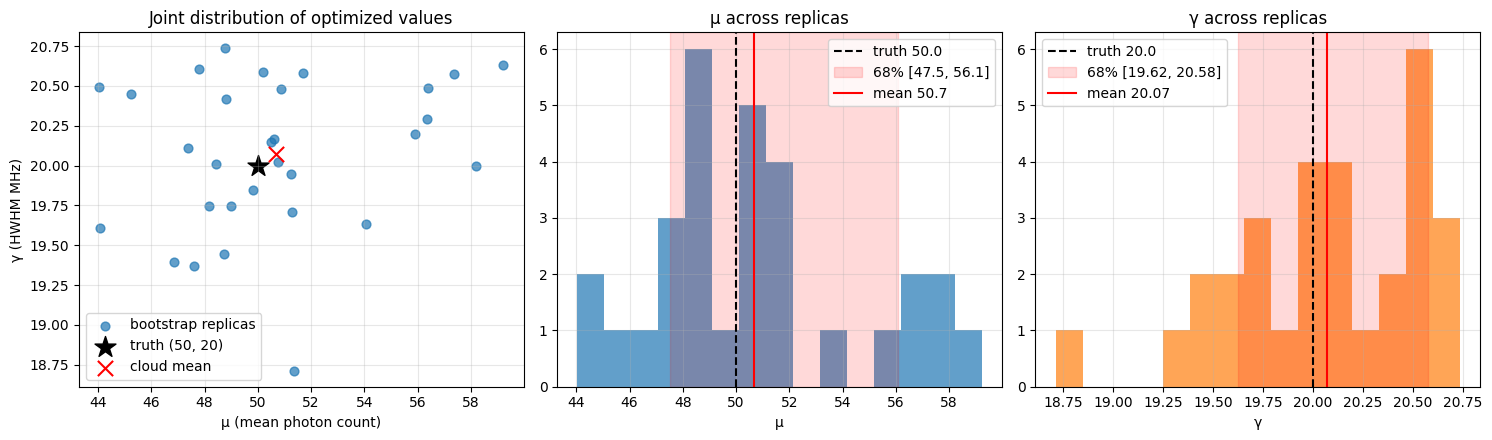

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- joint scatter ---
ax = axes[0]
ax.scatter(mus, gammas, s=40, alpha=0.7, color='#1f77b4', label='bootstrap replicas')
ax.scatter([NBAR_TRUE], [GAMMA_TRUE], marker='*', s=250, color='black', label='truth (50, 20)')
ax.scatter([mus.mean()], [gammas.mean()], marker='x', s=120, color='red', label='cloud mean')
ax.set_xlabel('μ (mean photon count)'); ax.set_ylabel('γ (HWHM MHz)')
ax.set_title('Joint distribution of optimized values')
ax.legend(); ax.grid(alpha=0.3)

# --- mu histogram ---
ax = axes[1]
ax.hist(mus, bins=15, alpha=0.7, color='#1f77b4')
ax.axvline(NBAR_TRUE, color='black', ls='--', lw=1.5, label=f'truth {NBAR_TRUE}')
lo, hi = np.percentile(mus, [16, 84])
ax.axvspan(lo, hi, color='red', alpha=0.15, label=f'68% [{lo:.1f}, {hi:.1f}]')
ax.axvline(mus.mean(), color='red', ls='-', lw=1.5, label=f'mean {mus.mean():.1f}')
ax.set_xlabel('μ'); ax.set_title('μ across replicas')
ax.legend(); ax.grid(alpha=0.3)

# --- gamma histogram ---
ax = axes[2]
ax.hist(gammas, bins=15, alpha=0.7, color='#ff7f0e')
ax.axvline(GAMMA_TRUE, color='black', ls='--', lw=1.5, label=f'truth {GAMMA_TRUE}')
lo, hi = np.percentile(gammas, [16, 84])
ax.axvspan(lo, hi, color='red', alpha=0.15, label=f'68% [{lo:.2f}, {hi:.2f}]')
ax.axvline(gammas.mean(), color='red', ls='-', lw=1.5, label=f'mean {gammas.mean():.2f}')
ax.set_xlabel('γ'); ax.set_title('γ across replicas')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_bootstrap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary & interpretation

- **Spread of μ and γ across replicas** = bootstrap uncertainty of the point estimate
- **Bias** = distance from the cloud center to the truth (only possible on synthetic data)
- **Coverage** = does the 68% interval contain the truth? (first calibration check)
- The joint scatter shows the μ–γ degeneracy direction if the data noise drives them in a correlated way.

**Next experiments (later):** Hessian-based uncertainty (12c as-is, finite differences), then the Poisson-likelihood Fisher information.


In [7]:
mu_lo68, mu_hi68 = np.percentile(mus, [16, 84])
mu_lo95, mu_hi95 = np.percentile(mus, [2.5, 97.5])
gam_lo68, gam_hi68 = np.percentile(gammas, [16, 84])
gam_lo95, gam_hi95 = np.percentile(gammas, [2.5, 97.5])

print("=" * 62)
print("  BOOTSTRAP UNCERTAINTY OF OPTIMIZED PARAMETERS")
print("=" * 62)
print(f"  μ:    {mus.mean():6.2f} ± {mus.std():5.2f}   (truth {NBAR_TRUE}, "
      f"bias {mus.mean()-NBAR_TRUE:+.2f})")
print(f"        68% interval [{mu_lo68:.2f}, {mu_hi68:.2f}]  "
      f"contains truth: {mu_lo68 <= NBAR_TRUE <= mu_hi68}")
print(f"        95% interval [{mu_lo95:.2f}, {mu_hi95:.2f}]  "
      f"contains truth: {mu_lo95 <= NBAR_TRUE <= mu_hi95}")
print(f"  γ:    {gammas.mean():6.2f} ± {gammas.std():5.2f}   (truth {GAMMA_TRUE}, "
      f"bias {gammas.mean()-GAMMA_TRUE:+.2f})")
print(f"        68% interval [{gam_lo68:.2f}, {gam_hi68:.2f}]  "
      f"contains truth: {gam_lo68 <= GAMMA_TRUE <= gam_hi68}")
print(f"        95% interval [{gam_lo95:.2f}, {gam_hi95:.2f}]  "
      f"contains truth: {gam_lo95 <= GAMMA_TRUE <= gam_hi95}")
print(f"  Final loss: {losses.mean():.2f} ± {losses.std():.2f}")
print("=" * 62)

  BOOTSTRAP UNCERTAINTY OF OPTIMIZED PARAMETERS
  μ:     50.69 ±  3.95   (truth 50.0, bias +0.69)
        68% interval [47.52, 56.07]  contains truth: True
        95% interval [44.07, 58.48]  contains truth: True
  γ:     20.07 ±  0.47   (truth 20.0, bias +0.07)
        68% interval [19.62, 20.58]  contains truth: True
        95% interval [19.19, 20.66]  contains truth: True
  Final loss: 1.77 ± 0.59
